# **1. Imports**

In [1]:
# 1.1. For working with files in Collab
import os

In [2]:
# 1.2. For read and configure the .csv file
import numpy  as np
import pandas as pd

In [3]:
# 1.3. For visualization purposes
import matplotlib.pyplot as plt
import seaborn           as sns

In [4]:
# 1.4. For dataset importing
import kagglehub

In [5]:
# 1.5. For spliting, models, and metrics
from sklearn.model_selection    import train_test_split
from sklearn.impute             import SimpleImputer  # for handling missing values
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.metrics            import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [6]:
# 1.6. For handling imbalanced data
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [7]:
# 1.7.
import tensorflow                as tf
from tensorflow.keras.models     import Sequential   # để xếp tầng tuyến tính (layer 1 -> layer 2 -> ...)
'''
Dense: fully-connected layer (linear + activation).
Dropout: regularization – tắt random một số node trong training để giảm overfitting
BatchNormalization: chuẩn hoá activation theo batch → giúp training ổn định hơn
Input: khai báo input layer cho model
'''
from tensorflow.keras.layers     import Dense, Dropout, BatchNormalization, Input
'''
EarlyStopping: callback dừng training sớm nếu val loss không giảm nữa → tránh overfitting, tiết kiệm thời gian
ReduceLROnPlateau: callback giảm learning rate khi metric không cải thiện
'''
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau
# to_categorical: chuyển y sang one-hot (cho multi-class)
from tensorflow.keras.utils      import to_categorical
# Adam: optimizer phổ biến (adaptive learning rate), cho NN.
from tensorflow.keras.optimizers import Adam

In [8]:
# 1.8. For stable results <-> consistent presentation
import random
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)      # cố định cho numpy
    tf.random.set_seed(seed)  # cố định trong TensorFlow

set_seed(42)

# **2. Dataset**

In [9]:
# 2.1. Data Collection from Kaggle
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
Dataset downloaded to: /kaggle/input/wine-quality-dataset


In [10]:
# 2.2. Locating the .csv file
file_name      = "WineQT.csv"
full_file_path = os.path.join(path, file_name)
print("Using CSV file:", full_file_path)

Using CSV file: /kaggle/input/wine-quality-dataset/WineQT.csv


In [11]:
# 2.3. Reading The File
data = pd.read_csv(full_file_path)

In [12]:
# 2.4. Displaying file's information
print("\nDataFrame loaded successfully. First 5 rows:")
print(data.head())

print("\nData shape:", data.shape)
print("\nColumns:", data.columns.tolist())

print("\nMissing values per column:")
print(data.isna().sum())


DataFrame loaded successfully. First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4    

In [13]:
# 2.5. Removing column "ID" to be tidier
if "Id" in data.columns:
    data = data.drop(columns=["Id"])
    print("\nDropped 'Id' column. New columns:")
    print(data.columns.tolist())


Dropped 'Id' column. New columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [14]:
# 2.6. Features Selection (separate the features and the lable)
lable_col = "quality"

x = data.drop(columns=[lable_col])
y = data[lable_col]

print("\nClass Distribution:")
print(y.value_counts(normalize=True))


Class Distribution:
quality
5    0.422572
6    0.404199
7    0.125109
4    0.028871
8    0.013998
3    0.005249
Name: proportion, dtype: float64


# **3. Split**

In [15]:
# 3.1. Test Set Split (20%)
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y,
    test_size=0.2,          # 20% cho test
    stratify=y,             # giữ tỉ lệ lớp
    random_state=42
)

In [16]:
# 3.2. Training and Validation Set Split (80%)
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.25,         # 25% of 80% = 20% tổng
    stratify=y_temp,
    random_state=42
)

In [17]:
# 3.3. Results Display
print("Training Shape   :", x_train.shape)
print("Validation Shape :", x_val.shape)
print("Test Shape       :", x_test.shape)

print("\nTraining Set Class Distribution:")
print(y_train.value_counts(normalize=True)) # normalize: to convert from ratio to %

print("\nValidation Set Class Distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest Set Class Distribution:")
print(y_test.value_counts(normalize=True))

Training Shape   : (685, 11)
Validation Shape : (229, 11)
Test Shape       : (229, 11)

Training Set Class Distribution:
quality
5    0.421898
6    0.404380
7    0.124088
4    0.029197
8    0.014599
3    0.005839
Name: proportion, dtype: float64

Validation Set Class Distribution:
quality
5    0.423581
6    0.406114
7    0.126638
4    0.026201
8    0.013100
3    0.004367
Name: proportion, dtype: float64

Test Set Class Distribution:
quality
5    0.423581
6    0.401747
7    0.126638
4    0.030568
8    0.013100
3    0.004367
Name: proportion, dtype: float64


# **4. Pre-process 1**

In [18]:
# 4.1. SimpleImputer: use median for missing values (recommended for numeric and outlier)
imputer = SimpleImputer(strategy="median")
# Fit/Calculate the training set and Transform/Fill in validation & testing set -> avoid data leakage
x_train_imputed = imputer.fit_transform(x_train)
x_val_imputed   = imputer.transform(x_val)
x_test_imputed  = imputer.transform(x_test)

In [19]:
# 4.2. StandardScaler: for better learning
scaler = StandardScaler()
# same as SimpleImputer
x_train_scaled = scaler.fit_transform(x_train_imputed)
x_val_scaled   = scaler.transform(x_val_imputed)
x_test_scaled  = scaler.transform(x_test_imputed)

In [20]:
# 4.3. Results Display
print("X_Train_Scaled Shape:", x_train_scaled.shape)
print("X_Val_Scaled Shape  :", x_val_scaled.shape)
print("X_Test_Scaled Shape  :", x_test_scaled.shape)

X_Train_Scaled Shape: (685, 11)
X_Val_Scaled Shape  : (229, 11)
X_Test_Scaled Shape  : (229, 11)


# **5. Pre-process 2**

In [21]:
# 5.1. Encode: convert origianl labels to 0...(n-1)
le = LabelEncoder()
# same as above
y_train_int = le.fit_transform(y_train)
y_val_int   = le.transform(y_val)
y_test_int  = le.transform(y_test)

num_classes = len(le.classes_)

print("Origianl Label Classes: ", le.classes_)
print("Encoded Label Classes: ", np.unique(y_train_int))

print("Encoded Training Label Distribution:")
unique, counts = np.unique(y_train_int, return_counts=True)
for k, c in zip(unique, counts):
    print(f"  Class {k} (Original Label: {le.classes_[k]}): {c} samples")

Origianl Label Classes:  [3 4 5 6 7 8]
Encoded Label Classes:  [0 1 2 3 4 5]
Encoded Training Label Distribution:
  Class 0 (Original Label: 3): 4 samples
  Class 1 (Original Label: 4): 20 samples
  Class 2 (Original Label: 5): 289 samples
  Class 3 (Original Label: 6): 277 samples
  Class 4 (Original Label: 7): 85 samples
  Class 5 (Original Label: 8): 10 samples


In [22]:
# 5.2. One-hot: convert encoded labels to vectors for DNN processing
# to_categorical: ma trận one-hot shape (n_samples, num_classes)
y_train_oh = to_categorical(y_train_int, num_classes=num_classes)
y_val_oh   = to_categorical(y_val_int,   num_classes=num_classes)
y_test_oh  = to_categorical(y_test_int,  num_classes=num_classes)

In [23]:
# 5.3. Results Display
print("Y_Train_Oh Shape: ", y_train_oh.shape)
print("Y_Val_Oh Shape: ", y_val_oh.shape)
print("Y_Test_Oh Shape: ", y_test_oh.shape)

Y_Train_Oh Shape:  (685, 6)
Y_Val_Oh Shape:  (229, 6)
Y_Test_Oh Shape:  (229, 6)


# **6. Pipelines**

## **6.1. DNN (No Imbalance Handling)**

In [24]:
x_train_dnn = x_train_scaled
y_train_dnn = y_train_oh

x_val       = x_val_scaled
y_val_cat   = y_val_oh

x_test      = x_test_scaled
y_test_cat  = y_test_oh

print("Model 1 - DNN (no resampling)")
print("  X_train_dnn shape:", x_train_dnn.shape, "| y_train_dnn shape:", y_train_dnn.shape)
print("  X_val shape      :", x_val.shape,       "| y_val_cat shape  :", y_val_cat.shape)
print("  X_test shape     :", x_test.shape,      "| y_test_cat shape :", y_test_cat.shape)

Model 1 - DNN (no resampling)
  X_train_dnn shape: (685, 11) | y_train_dnn shape: (685, 6)
  X_val shape      : (229, 11) | y_val_cat shape  : (229, 6)
  X_test shape     : (229, 11) | y_test_cat shape : (229, 6)


## **6.2. DNN + Mixed Imbalanced Handling Method(Over + Under Sampling)**

In [25]:
# SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
x_train_over, y_train_over_int = smote.fit_resample(
    x_train_scaled,
    y_train_int
)
print("\nAfter SMOTE:")
print("  X_train_over shape:", x_train_over.shape)
print("  Class distribution:", pd.Series(y_train_over_int).value_counts().sort_index().to_dict())

# Undersampling
rus = RandomUnderSampler(random_state=42)
x_train_mixed, y_train_mixed_int = rus.fit_resample(
    x_train_over,
    y_train_over_int
)

print("\nAfter Mixed (SMOTE + Undersampling):")
print("  X_train_mixed shape:", x_train_mixed.shape)
print("  Class distribution  :", pd.Series(y_train_mixed_int).value_counts().sort_index().to_dict())

# Re one-hot for DNN
y_train_mixed_oh = to_categorical(
    y_train_mixed_int,
    num_classes=num_classes
)
print(" y_train_mixed_oh shape:", y_train_mixed_oh.shape)


After SMOTE:
  X_train_over shape: (1734, 11)
  Class distribution: {0: 289, 1: 289, 2: 289, 3: 289, 4: 289, 5: 289}

After Mixed (SMOTE + Undersampling):
  X_train_mixed shape: (1734, 11)
  Class distribution  : {0: 289, 1: 289, 2: 289, 3: 289, 4: 289, 5: 289}
 y_train_mixed_oh shape: (1734, 6)


# **7. Build + Train**

In [26]:
def build_model(input_dim: int, num_classes: int) -> tf.keras.Model:
    """
    Simple DNN for tabular multi-class classification.
    - Input:  numeric features (already imputed + scaled)
    - 2 hidden layers: Dense + ReLU + BatchNorm + Dropout
    - Output: softmax over num_classes (one-hot labels)
    """
    model = Sequential([
        # Input layer: expect vectors of shape (input_dim,)
        Input(shape=(input_dim,)),

        # Hidden layer 1
        Dense(64, activation="relu"),   # 64 units, ReLU non-linearity
        BatchNormalization(),           # stabilize activations across batches
        Dropout(0.3),                   # regularization to reduce overfitting

        # Hidden layer 2
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        # Output layer: one neuron per class, softmax for probabilities
        Dense(num_classes, activation="softmax")
    ])

    # Optimizer + loss + metrics
    opt = Adam(learning_rate=0.001)
    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",   # one-hot targets
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    )
    return model

# Số features (columns) sau preprocessing: dùng làm input_dim
input_dim = x_train_scaled.shape[1]

input_dim = x_train_dnn.shape[1]   # = 11 features
EPOCHS    = 100
BATCH_SIZE = 64

In [27]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    mode="min",
    verbose=1
)

In [28]:
model_dnn = build_model(input_dim=input_dim, num_classes=num_classes)
history_dnn = model_dnn.fit(
    x_train_dnn, y_train_dnn,
    validation_data=(x_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.1816 - loss: 2.5622 - precision: 0.2333 - recall: 0.1071 - val_accuracy: 0.2838 - val_loss: 1.7314 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2402 - loss: 2.3246 - precision: 0.2463 - recall: 0.0978 - val_accuracy: 0.3100 - val_loss: 1.7068 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2547 - loss: 2.1620 - precision: 0.3653 - recall: 0.1192 - val_accuracy: 0.3581 - val_loss: 1.6803 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2971 - loss: 1.9320 - precision: 0.4253 - recall: 0.1359 - val_accuracy: 0.3886 - val_loss: 1.6513 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
11/11 ━━━━━━━━━━━━━━

In [29]:
model_mixed = build_model(input_dim=input_dim, num_classes=num_classes)
history_mixed = model_mixed.fit(
    x_train_mixed, y_train_mixed_oh,
    validation_data=(x_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2139 - loss: 2.1940 - precision: 0.2213 - recall: 0.0875 - val_accuracy: 0.2183 - val_loss: 1.7428 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3700 - loss: 1.6694 - precision: 0.4717 - recall: 0.1907 - val_accuracy: 0.2358 - val_loss: 1.7029 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4424 - loss: 1.4299 - precision: 0.5577 - recall: 0.2671 - val_accuracy: 0.2533 - val_loss: 1.6677 - val_precision: 0.2222 - val_recall: 0.0087 - learning_rate: 0.0010
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4773 - loss: 1.3631 - precision: 0.5863 - recall: 0.3084 - val_accuracy: 0.2926 - val_loss: 1.6156 - val_precision: 0.3529 - val_recall: 0.0262 - learning_rate: 0.0010
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

In [30]:
def plot_history(history, title: str = ""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    # Accuracy
    if "accuracy" in hist and "val_accuracy" in hist:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, hist["accuracy"], label="train acc")
        plt.plot(epochs, hist["val_accuracy"], label="val acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"{title} - Accuracy")
        plt.legend()

    plt.tight_layout()
    plt.show()

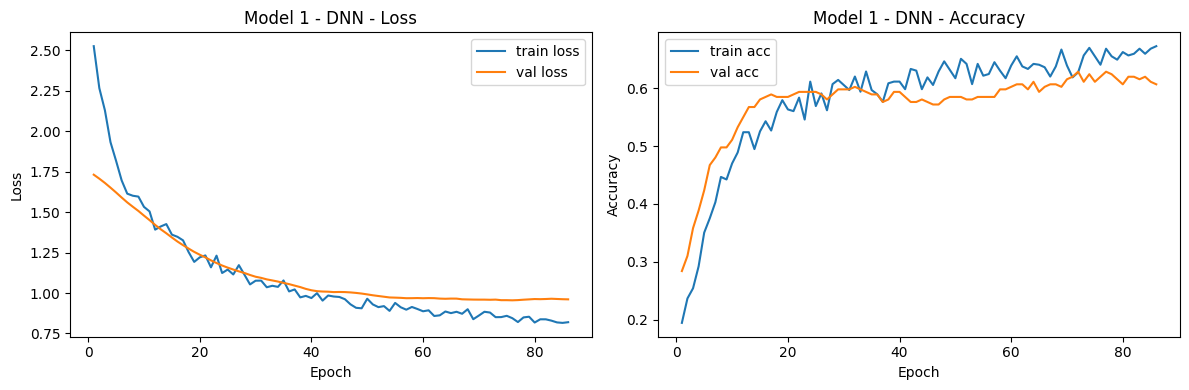

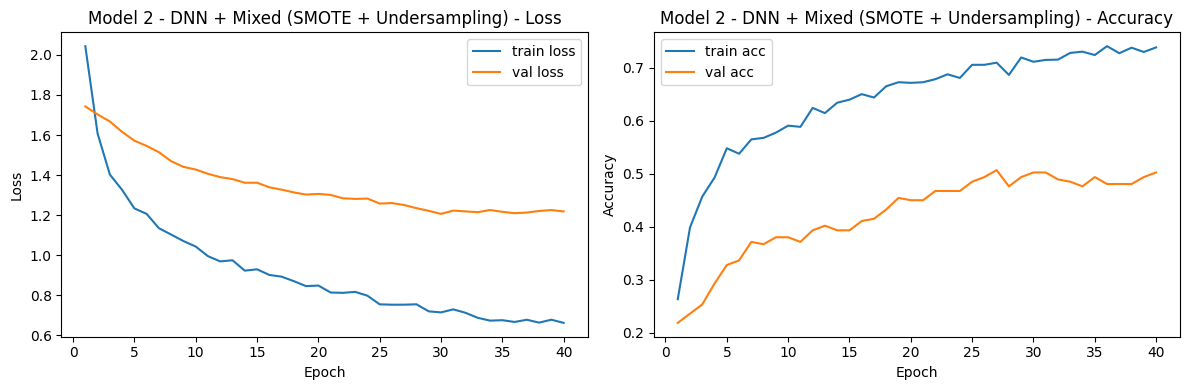

In [31]:
plot_history(history_dnn,   title="Model 1 - DNN")
plot_history(history_mixed, title="Model 2 - DNN + Mixed (SMOTE + Undersampling)")

# **8. Evaluate**

In [32]:
def evaluate_model(model, name: str) -> None:
    # ==========================
    # 1. VALIDATION
    # ==========================
    print(f"\n===== {name}: VALIDATION =====")
    val_loss, val_acc, val_prec, val_rec = model.evaluate(
        x_val_scaled, y_val_oh, verbose=0
    )
    print(f"Val Loss              : {val_loss:.4f}")
    print(f"Val Accuracy          : {val_acc:.4f}")
    print(f"Val Precision (micro) : {val_prec:.4f}")
    print(f"Val Recall (micro)    : {val_rec:.4f}")

    # Dự đoán trên validation
    y_val_pred_prob = model.predict(x_val_scaled, verbose=0)
    y_val_pred_int  = np.argmax(y_val_pred_prob, axis=1)

    # Đổi về nhãn gốc (quality) cho dễ đọc
    y_val_true_labels = le.inverse_transform(y_val_int)
    y_val_pred_labels = le.inverse_transform(y_val_pred_int)

    # Classification report (per-class precision/recall/F1)
    print("\nClassification Report (Validation, Original Labels):")
    print(
        classification_report(
            y_val_true_labels,
            y_val_pred_labels,
            labels=le.classes_
        )
    )

    # Confusion matrix
    cm_val = confusion_matrix(
        y_val_true_labels,
        y_val_pred_labels,
        labels=le.classes_
    )
    cm_val_df = pd.DataFrame(
        cm_val,
        index=[f"true_{c}" for c in le.classes_],
        columns=[f"pred_{c}" for c in le.classes_]
    )
    print("Confusion Matrix (Validation, counts):")
    print(cm_val_df)

    # ==========================
    # 2. TEST
    # ==========================
    print(f"\n===== {name}: TEST =====")
    test_loss, test_acc, test_prec, test_rec = model.evaluate(
        x_test_scaled, y_test_oh, verbose=0
    )
    print(f"Test Loss             : {test_loss:.4f}")
    print(f"Test Accuracy         : {test_acc:.4f}")
    print(f"Test Precision (micro): {test_prec:.4f}")
    print(f"Test Recall (micro)   : {test_rec:.4f}")

    # Dự đoán trên test
    y_test_pred_prob = model.predict(x_test_scaled, verbose=0)
    y_test_pred_int  = np.argmax(y_test_pred_prob, axis=1)

    # Đổi về nhãn gốc (quality)
    y_test_true_labels = le.inverse_transform(y_test_int)
    y_test_pred_labels = le.inverse_transform(y_test_pred_int)

    # Classification report (Test)
    print("\nClassification Report (Test, Original Labels):")
    print(
        classification_report(
            y_test_true_labels,
            y_test_pred_labels,
            labels=le.classes_
        )
    )

    # Confusion matrix
    cm_test = confusion_matrix(
        y_test_true_labels,
        y_test_pred_labels,
        labels=le.classes_
    )
    cm_test_df = pd.DataFrame(
        cm_test,
        index=[f"true_{c}" for c in le.classes_],
        columns=[f"pred_{c}" for c in le.classes_]
    )
    print("Confusion Matrix (Test, counts):")
    print(cm_test_df)

In [33]:
evaluate_model(model_dnn,   name="Model 1 - DNN (No Resampling)")
evaluate_model(model_mixed, name="Model 2 - DNN + Mixed Method (SMOTE + Undersampling)")


===== Model 1 - DNN (no resampling): VALIDATION =====
Val loss              : 0.9548
Val accuracy          : 0.6201
Val precision (micro) : 0.6480
Val recall (micro)    : 0.5066

Classification Report (Validation, original labels):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.67      0.79      0.73        97
           6       0.61      0.58      0.59        93
           7       0.50      0.38      0.43        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.30      0.29      0.29       229
weighted avg       0.59      0.62      0.60       229

Confusion Matrix (Validation, counts):
        pred_3  pred_4  pred_5  pred_6  pred_7  pred_8
true_3       0       1       0       0       0       0
true_4       0       0       5       1       0       0
true_5       0      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report (Test, original labels):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.71      0.78      0.75        97
           6       0.63      0.62      0.63        92
           7       0.48      0.52      0.50        29
           8       0.00      0.00      0.00         3

    accuracy                           0.65       229
   macro avg       0.30      0.32      0.31       229
weighted avg       0.62      0.65      0.63       229

Confusion Matrix (Test, counts):
        pred_3  pred_4  pred_5  pred_6  pred_7  pred_8
true_3       0       0       1       0       0       0
true_4       0       0       4       3       0       0
true_5       0       0      76      19       2       0
true_6       0       1      23      57      11       0
true_7       0       0       3      11      15       0
true_8       0       0       0       0       3

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report (Validation, original labels):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.09      0.50      0.16         6
           5       0.71      0.56      0.62        97
           6       0.58      0.45      0.51        93
           7       0.48      0.52      0.50        29
           8       0.08      0.33      0.13         3

    accuracy                           0.50       229
   macro avg       0.32      0.39      0.32       229
weighted avg       0.60      0.50      0.54       229

Confusion Matrix (Validation, counts):
        pred_3  pred_4  pred_5  pred_6  pred_7  pred_8
true_3       0       1       0       0       0       0
true_4       0       3       3       0       0       0
true_5       4      16      54      23       0       0
true_6       1      10      18      42      14       8
true_7       0       2       1       8      15       3
true_8       0       0       0    